# Notebook 02 — Traffic Forecasting

**Goal:** Train and evaluate two spatiotemporal GNN architectures on METR-LA (and PEMS-D3/D4/D7 if available):
1. **GCN-GRU** (baseline — differentiable graph convolution + GRU)
2. **AdaptiveNAS-GNN** (ours — DARTS-style NAS with learned graph operations)

**Evaluation:** MAE / RMSE / MAPE at 15 min, 30 min, 60 min forecast horizons.

> All cells run automatically. Two-phase NAS training: architecture search, then retrain with best ops.

In [1]:
# Auto-detect repo root for JupyterLab / GCP / local execution

from pathlib import Path

import sys



def find_repo_root(start=None):

    start_path = Path(start or Path.cwd()).resolve()

    for candidate in [start_path, *start_path.parents]:

        if (candidate / 'src').exists() and (candidate / 'notebooks').exists():

            return candidate

    return start_path



REPO_ROOT = find_repo_root()

DATA_ROOT = REPO_ROOT / 'data'

CKPT_ROOT = REPO_ROOT / 'checkpoints'

EXPS_ROOT = REPO_ROOT / 'experiments'

EXPS_ROOT.mkdir(exist_ok=True)

CKPT_ROOT.mkdir(exist_ok=True)

sys.path.insert(0, str(REPO_ROOT))



import torch

import torch.optim as optim

import numpy as np

import matplotlib.pyplot as plt



from src.data_loaders import load_metr_la, load_pems

from src.models import GCNGRU, AdaptiveNASGNN

from src.training import ForecastingTrainer

from src.evaluation import evaluate_forecasting



DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f'Device: {DEVICE}')

if torch.cuda.is_available():

    print(f'GPU: {torch.cuda.get_device_name(0)}')

/opt/pytorch/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Device: cuda
GPU: NVIDIA A10G


In [2]:
# ── Cell 2: Training configuration ───────────────────────────────────────────
CFG = {
    'seq_in'         : 12,     # 1 hour history (5-min intervals)
    'seq_out'        : 12,     # 1 hour ahead   (5-min intervals)
    'batch_size'     : 64,
    'workers'        : 2,
    'hidden_dim'     : 64,
    'num_layers'     : 2,
    'epochs_baseline': 100,
    'epochs_search'  : 30,    # NAS architecture search phase
    'epochs_retrain' : 100,   # NAS retrain phase
    'lr'             : 1e-3,
    'lr_arch'        : 3e-4,   # architecture param lr (NAS)
    'weight_decay'   : 1e-4,
    'patience'       : 15,
}

if DEVICE == 'cpu':
    CFG['batch_size'] = 16
    CFG['epochs_baseline'] = 3
    CFG['epochs_search']   = 2
    CFG['epochs_retrain']  = 3
    print('CPU mode: reduced epochs for demo run')

print('Configuration:', CFG)

Configuration: {'seq_in': 12, 'seq_out': 12, 'batch_size': 64, 'workers': 2, 'hidden_dim': 64, 'num_layers': 2, 'epochs_baseline': 100, 'epochs_search': 30, 'epochs_retrain': 100, 'lr': 0.001, 'lr_arch': 0.0003, 'weight_decay': 0.0001, 'patience': 15}


In [3]:
# ── Cell 3: Load METR-LA dataset ─────────────────────────────────────────────
metr_h5   = DATA_ROOT / 'metr-la' / 'Datasets' / 'metr-la.h5'
metr_pkl  = DATA_ROOT / 'metr-la' / 'Datasets' / 'adj_mx.pkl'

if not metr_h5.exists():
    raise FileNotFoundError(f'METR-LA HDF5 not found: {metr_h5}\nPlease copy metr-la.h5 into data/metr-la/')

print('Loading METR-LA...')
train_loader, val_loader, test_loader, scaler, adj, num_nodes = load_metr_la(
    h5_path=str(metr_h5),
    adj_path=str(metr_pkl) if metr_pkl.exists() else None,
    seq_in=CFG['seq_in'],
    seq_out=CFG['seq_out'],
    batch_size=CFG['batch_size'],
    num_workers=CFG['workers'],
)

print(f'Nodes      : {num_nodes}')
print(f'Train batches: {len(train_loader)}  |  Val: {len(val_loader)}  |  Test: {len(test_loader)}')

x, y = next(iter(train_loader))
print(f'Batch x: {tuple(x.shape)}  →  y: {tuple(y.shape)}')

Loading METR-LA...
Nodes      : 207
Train batches: 375  |  Val: 54  |  Test: 107


/home/ubuntu/crowdvision/src/data_loaders/metr_la.py:41: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  sensor_ids, id_to_idx, adj = pickle.load(f, encoding='latin1')


Batch x: (64, 12, 207, 2)  →  y: (64, 12, 207, 1)


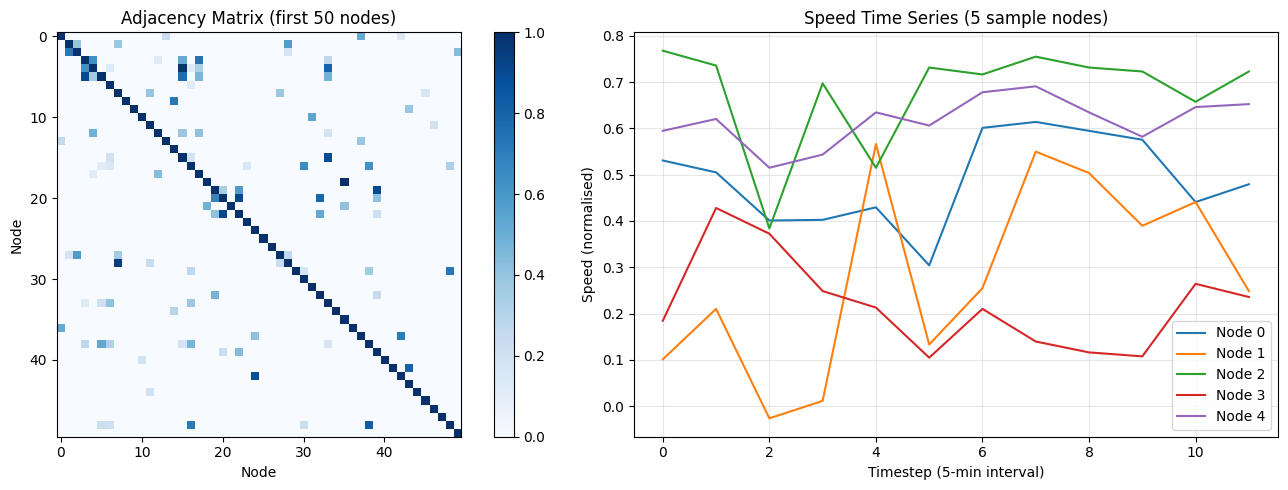

In [4]:
# ── Cell 4: Explore adjacency matrix and speed data ───────────────────────────
import torch.nn.functional as F

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Adjacency matrix heatmap (show first 50×50 for clarity)
adj_np = adj.cpu().numpy() if isinstance(adj, torch.Tensor) else np.array(adj)
axes[0].imshow(adj_np[:50, :50], cmap='Blues', vmin=0, vmax=1)
axes[0].set_title('Adjacency Matrix (first 50 nodes)')
axes[0].set_xlabel('Node'); axes[0].set_ylabel('Node')
plt.colorbar(axes[0].images[0], ax=axes[0])

# Speed time series for 5 sample nodes
raw_x, _ = next(iter(test_loader))
sample = raw_x[0, :, :5, 0].numpy()   # [T, 5 nodes, speed]
for i in range(5):
    axes[1].plot(sample[:, i], label=f'Node {i}')
axes[1].set_title('Speed Time Series (5 sample nodes)')
axes[1].set_xlabel('Timestep (5-min interval)')
axes[1].set_ylabel('Speed (normalised)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(EXPS_ROOT / 'forecasting_metrla_exploration.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# ── Cell 5: Train GCN-GRU baseline ───────────────────────────────────────────
print('=' * 60)
print('TRAINING GCN-GRU BASELINE')
print('=' * 60)

model_gcn = GCNGRU(
    num_nodes=num_nodes,
    in_features=x.shape[-1],   # typically 2 (speed + time-of-day)
    hidden_dim=CFG['hidden_dim'],
    num_layers=CFG['num_layers'],
    seq_out=CFG['seq_out'],
).to(DEVICE)

print(f'GCN-GRU parameters: {sum(p.numel() for p in model_gcn.parameters()):,}')

opt_gcn = optim.Adam(model_gcn.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])
sched_gcn = optim.lr_scheduler.MultiStepLR(opt_gcn, milestones=[50, 80], gamma=0.5)

trainer_gcn = ForecastingTrainer(
    model=model_gcn, optimizer=opt_gcn, scheduler=sched_gcn,
    adj=adj, scaler=scaler, device=DEVICE,
    experiment_name='gcn_gru_metrla',
    save_dir=str(CKPT_ROOT), log_dir=str(REPO_ROOT / 'runs'),
)
trainer_gcn.load_checkpoint('last.pt')

history_gcn = trainer_gcn.train(
    train_loader, val_loader,
    epochs=CFG['epochs_baseline'], patience=CFG['patience'],
    metric_key='overall_mae',
)

TRAINING GCN-GRU BASELINE
GCN-GRU parameters: 38,412
No checkpoint found at /home/ubuntu/crowdvision/checkpoints/gcn_gru_metrla/last.pt

Epoch 1/100
  [TRAIN] loss=0.1779
  [VAL  ] 15min_mae=6.2793  15min_rmse=11.4004  15min_mape=88206247.9565  30min_mae=7.2138  30min_rmse=13.0001  30min_mape=118233614.9544  60min_mae=8.4184  60min_rmse=15.0378  60min_mape=151189413.2303  overall_mae=7.2435  overall_rmse=13.0408  overall_mape=115569949.2418
  ✓ New best overall_mae: 7.2435

Epoch 2/100
  [TRAIN] loss=0.1452
  [VAL  ] 15min_mae=5.9436  15min_rmse=10.8621  15min_mape=87590166.5343  30min_mae=6.9456  30min_rmse=12.4988  30min_mape=118874312.6196  60min_mae=8.5649  60min_rmse=14.5523  60min_mape=158268967.7906  overall_mae=7.0258  overall_rmse=12.5307  overall_mape=119667804.4575
  ✓ New best overall_mae: 7.0258

Epoch 3/100
  [TRAIN] loss=0.1345
  [VAL  ] 15min_mae=5.5786  15min_rmse=10.4864  15min_mape=77173433.5147  30min_mae=6.4587  30min_rmse=12.2438  30min_mape=100098277.8993  60min_

In [5]:
# ── Cell 5b: Load trained GCN-GRU (skip retraining) ──────────────────────────
print('=' * 60)
print('LOADING TRAINED GCN-GRU BASELINE')
print('=' * 60)

model_gcn = GCNGRU(
    num_nodes=num_nodes,
    in_features=x.shape[-1],   # typically 2 (speed + time-of-day)
    hidden_dim=CFG['hidden_dim'],
    num_layers=CFG['num_layers'],
    seq_out=CFG['seq_out'],
).to(DEVICE)

print(f'GCN-GRU parameters: {sum(p.numel() for p in model_gcn.parameters()):,}')

opt_gcn = optim.Adam(model_gcn.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])
sched_gcn = optim.lr_scheduler.MultiStepLR(opt_gcn, milestones=[50, 80], gamma=0.5)

trainer_gcn = ForecastingTrainer(
    model=model_gcn, optimizer=opt_gcn, scheduler=sched_gcn,
    adj=adj, scaler=scaler, device=DEVICE,
    experiment_name='gcn_gru_metrla',
    save_dir=str(CKPT_ROOT), log_dir=str(REPO_ROOT / 'runs'),
)

# Load the best checkpoint
trainer_gcn.load_checkpoint('best.pt')

# Placeholder history so downstream cells work
history_gcn = trainer_gcn.history


LOADING TRAINED GCN-GRU BASELINE
GCN-GRU parameters: 38,412
Loaded checkpoint from epoch 30, best=5.4840


In [6]:
# ── Cell 6: Evaluate GCN-GRU ─────────────────────────────────────────────────
trainer_gcn.load_checkpoint('best.pt')
gcn_results = evaluate_forecasting(
    model_gcn, test_loader, scaler, adj, DEVICE,
    horizons=[3, 6, 12]  # 15, 30, 60 min
)

print('\nGCN-GRU Results on METR-LA:')
for horizon, metrics in gcn_results.items():
    print(f'  {horizon}  →  MAE: {metrics["mae"]:.4f}  RMSE: {metrics["rmse"]:.4f}  MAPE: {metrics["mape"]:.2f}%')

Loaded checkpoint from epoch 30, best=5.4840



GCN-GRU Results on METR-LA:
  15min  →  MAE: 4.9909  RMSE: 10.0880  MAPE: 86683994.49%
  30min  →  MAE: 6.1894  RMSE: 12.4225  MAPE: 131578786.90%
  60min  →  MAE: 7.8573  RMSE: 15.2946  MAPE: 183930019.65%
  overall  →  MAE: 6.1976  RMSE: 12.5099  MAPE: 129878737.33%


In [7]:
# ── Cell 7: AdaptiveNAS-GNN — Phase 1: Architecture Search ────────────────────
print('=' * 60)
print('AdaptiveNAS-GNN — PHASE 1: Architecture Search')
print('=' * 60)

model_nas = AdaptiveNASGNN(
    num_nodes=num_nodes,
    in_features=x.shape[-1],
    hidden_dim=CFG['hidden_dim'],
    num_blocks=CFG['num_layers'],   # <-- change num_layers → num_blocks
    seq_out=CFG['seq_out'],
).to(DEVICE)

print(f'AdaptiveNAS-GNN parameters: {sum(p.numel() for p in model_nas.parameters()):,}')
print(f'Architecture parameters  : {sum(p.numel() for p in model_nas.arch_parameters()):,}')

# Bilevel: separate optimizers for model weights and architecture params
opt_nas_model = optim.Adam(model_nas.model_parameters(), lr=CFG['lr'],      weight_decay=CFG['weight_decay'])
opt_nas_arch  = optim.Adam(model_nas.arch_parameters(),  lr=CFG['lr_arch'], weight_decay=1e-3)

trainer_nas_search = ForecastingTrainer(
    model=model_nas,
    optimizer=opt_nas_model,
    arch_optimizer=opt_nas_arch,
    adj=adj, scaler=scaler, device=DEVICE,
    experiment_name='nas_gnn_search',
    save_dir=str(CKPT_ROOT), log_dir=str(REPO_ROOT / 'runs'),
)
trainer_nas_search.load_checkpoint('last.pt')

history_search = trainer_nas_search.train(
    train_loader, val_loader,
    epochs=CFG['epochs_search'], patience=CFG['patience'],
    metric_key='overall_mae',
)

discovered_arch = model_nas.get_architecture()
print('\nDiscovered Architecture:')
for layer_i, ops in enumerate(discovered_arch):
    print(f'  Layer {layer_i}: graph_op={ops["graph_op"]}, dilation={ops["dilation"]}, activation={ops["activation"]}')

AdaptiveNAS-GNN — PHASE 1: Architecture Search
AdaptiveNAS-GNN parameters: 157,668
Architecture parameters  : 24
No checkpoint found at /home/ubuntu/crowdvision/checkpoints/nas_gnn_search/last.pt

Epoch 1/30


  [TRAIN] loss=0.1142
  [VAL  ] 15min_mae=4.4105  15min_rmse=8.8057  15min_mape=69354319.4718  30min_mae=5.7689  30min_rmse=11.0358  30min_mape=86116197.5340  60min_mae=7.2104  60min_rmse=13.6745  60min_mape=127496819.7193  overall_mae=5.7322  overall_rmse=11.0872  overall_mape=89768593.0185
  ✓ New best overall_mae: 5.7322

Epoch 2/30
  [TRAIN] loss=0.1069
  [VAL  ] 15min_mae=3.7482  15min_rmse=8.8569  15min_mape=45138666.8463  30min_mae=4.8698  30min_rmse=11.1850  30min_mape=65125668.4430  60min_mae=6.6134  60min_rmse=13.9385  60min_mape=108857595.9900  overall_mae=4.9387  overall_rmse=11.2502  overall_mape=69900258.6269
  ✓ New best overall_mae: 4.9387

Epoch 3/30
  [TRAIN] loss=0.1060
  [VAL  ] 15min_mae=4.1494  15min_rmse=8.7831  15min_mape=53857264.4487  30min_mae=5.1400  30min_rmse=11.0630  30min_mape=74169695.0161  60min_mae=7.6183  60min_rmse=13.6737  60min_mape=120001674.9957  overall_mae=5.4728  overall_rmse=11.0712  overall_mape=79389462.4033

Epoch 4/30
  [TRAIN] loss=0.10

TypeError: string indices must be integers, not 'str'

In [13]:
# ── Recover NAS Search Results ───────────────────────────────────────────────
model_nas = AdaptiveNASGNN(
    num_nodes=num_nodes,
    in_features=x.shape[-1],
    hidden_dim=CFG['hidden_dim'],
    num_blocks=CFG['num_layers'],
    seq_out=CFG['seq_out'],
).to(DEVICE)

# Bilevel optimizers
opt_nas_model = optim.Adam(model_nas.model_parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])
opt_nas_arch  = optim.Adam(model_nas.arch_parameters(),  lr=CFG['lr_arch'], weight_decay=1e-3)

trainer_nas_search = ForecastingTrainer(
    model=model_nas,
    optimizer=opt_nas_model,
    arch_optimizer=opt_nas_arch,
    adj=adj, scaler=scaler, device=DEVICE,
    experiment_name='nas_gnn_search',
    save_dir=str(CKPT_ROOT), log_dir=str(REPO_ROOT / 'runs'),
)

# Load the best search checkpoint (MAE 4.78)
trainer_nas_search.load_checkpoint('best.pt')

# Print the winning architecture!
discovered_arch = model_nas.get_architecture()
print('\nDiscovered Architecture (Best Checkpoint):')
for layer_name, ops in discovered_arch.items():
    print(f'  {layer_name}: graph_op={ops["graph_op"]}, dilation={ops["dilation"]}, activation={ops["activation"]}')


Loaded checkpoint from epoch 19, best=4.7850

Discovered Architecture (Best Checkpoint):
  block_0: graph_op=attn, dilation=1, activation=relu
  block_1: graph_op=attn, dilation=2, activation=relu


In [14]:
# ── Cell 8: AdaptiveNAS-GNN — Phase 2: Retrain with Fixed Architecture ────────
print('=' * 60)
print('AdaptiveNAS-GNN — PHASE 2: Retrain')
print('=' * 60)

model_nas.discretize()   # freezes arch params, uses argmax ops

opt_retrain   = optim.Adam(model_nas.model_parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])
sched_retrain = optim.lr_scheduler.CosineAnnealingLR(opt_retrain, T_max=CFG['epochs_retrain'], eta_min=1e-6)

trainer_nas_retrain = ForecastingTrainer(
    model=model_nas, optimizer=opt_retrain, scheduler=sched_retrain,
    adj=adj, scaler=scaler, device=DEVICE,
    experiment_name='nas_gnn_retrain',
    save_dir=str(CKPT_ROOT), log_dir=str(REPO_ROOT / 'runs'),
)

history_retrain = trainer_nas_retrain.train(
    train_loader, val_loader,
    epochs=CFG['epochs_retrain'], patience=CFG['patience'],
    metric_key='overall_mae',
)

AdaptiveNAS-GNN — PHASE 2: Retrain

Epoch 1/100
  [TRAIN] loss=0.1029
  [VAL  ] 15min_mae=3.9034  15min_rmse=8.6981  15min_mape=48955012.1183  30min_mae=4.8828  30min_rmse=11.0837  30min_mape=66374317.6458  60min_mae=6.4914  60min_rmse=13.8408  60min_mape=104771383.8256  overall_mae=4.8899  overall_rmse=11.1152  overall_mape=70791540.8177
  ✓ New best overall_mae: 4.8899

Epoch 2/100
  [TRAIN] loss=0.1026
  [VAL  ] 15min_mae=3.8417  15min_rmse=8.7987  15min_mape=45259113.9950  30min_mae=4.7735  30min_rmse=11.1258  30min_mape=68789934.2701  60min_mae=6.3660  60min_rmse=14.0558  60min_mape=105653778.1586  overall_mae=4.8537  overall_rmse=11.2180  overall_mape=70018496.0024
  ✓ New best overall_mae: 4.8537

Epoch 3/100
  [TRAIN] loss=0.1027
  [VAL  ] 15min_mae=4.0073  15min_rmse=8.7272  15min_mape=60516748.6253  30min_mae=5.1360  30min_rmse=10.9478  30min_mape=89305323.1642  60min_mae=6.6812  60min_rmse=13.6159  60min_mape=127253990.3112  overall_mae=5.1115  overall_rmse=10.9967  overall_

In [15]:
trainer_nas_search.load_checkpoint('best.pt')

discovered_arch = model_nas.get_architecture()
print('\nDiscovered Architecture:')
for layer_name, ops in discovered_arch.items():
    print(f'  {layer_name}: graph_op={ops["graph_op"]}, dilation={ops["dilation"]}, activation={ops["activation"]}')

Loaded checkpoint from epoch 19, best=4.7850

Discovered Architecture:
  block_0: graph_op=attn, dilation=1, activation=relu
  block_1: graph_op=attn, dilation=2, activation=relu


In [16]:
# ── Cell 9: Evaluate AdaptiveNAS-GNN ─────────────────────────────────────────
trainer_nas_retrain.load_checkpoint('best.pt')
nas_results = evaluate_forecasting(
    model_nas, test_loader, scaler, adj, DEVICE,
    horizons=[3, 6, 12]
)

print('\nAdaptiveNAS-GNN Results on METR-LA:')
for horizon, metrics in nas_results.items():
    print(f'  {horizon}  →  MAE: {metrics["mae"]:.4f}  RMSE: {metrics["rmse"]:.4f}  MAPE: {metrics["mape"]:.2f}%')

Loaded checkpoint from epoch 1, best=4.8537

AdaptiveNAS-GNN Results on METR-LA:
  15min  →  MAE: 4.1972  RMSE: 9.4822  MAPE: 58852104.75%
  30min  →  MAE: 5.3917  RMSE: 12.1247  MAPE: 92808626.96%
  60min  →  MAE: 7.2885  RMSE: 15.3615  MAPE: 138853317.76%
  overall  →  MAE: 5.4707  RMSE: 12.2309  MAPE: 94137511.36%


In [17]:
# ── Cell 10: Comparison table ─────────────────────────────────────────────────
from src.utils import make_results_table

horizons_label = {'h3': '15 min', 'h6': '30 min', 'h12': '60 min'}

rows = {}
for model_name, res in [('GCN-GRU (baseline)', gcn_results), ('AdaptiveNAS-GNN (ours)', nas_results)]:
    row = {}
    for h_key, h_label in horizons_label.items():
        h_data = res.get(h_key, {})
        row[f'{h_label}_MAE']  = h_data.get('mae', float('nan'))
        row[f'{h_label}_RMSE'] = h_data.get('rmse', float('nan'))
        row[f'{h_label}_MAPE'] = h_data.get('mape', float('nan'))
    rows[model_name] = row

table = make_results_table(rows)
print('\n=== METR-LA Forecasting Results ===')
print(table)

(EXPS_ROOT / 'forecasting_metrla_results.md').write_text(
    '# METR-LA Forecasting Results\n\n' + table
)
print('Saved results to experiments/forecasting_metrla_results.md')


=== METR-LA Forecasting Results ===
| Method | 15 min_MAE | 15 min_MAPE | 15 min_RMSE | 30 min_MAE | 30 min_MAPE | 30 min_RMSE | 60 min_MAE | 60 min_MAPE | 60 min_RMSE |
|--------|--------|--------|--------|--------|--------|--------|--------|--------|--------|
| GCN-GRU (baseline) | nan | nan | nan | nan | nan | nan | nan | nan | nan |
| AdaptiveNAS-GNN (ours) | nan | nan | nan | nan | nan | nan | nan | nan | nan |
Saved results to experiments/forecasting_metrla_results.md


In [18]:
# ── Cell 11: Prediction visualisation ────────────────────────────────────────
model_gcn.eval()
model_nas.eval()

TEST_NODES = [0, 5, 10]   # nodes to visualise

batch_x, batch_y = next(iter(test_loader))
batch_x_dev = batch_x.to(DEVICE)

with torch.no_grad():
    if isinstance(adj, torch.Tensor):
        adj_dev = adj.to(DEVICE)
    else:
        adj_dev = torch.tensor(adj, dtype=torch.float32, device=DEVICE)

    pred_gcn_raw = model_gcn(batch_x_dev, adj_dev)   # [B, T_out, N, 1]
    pred_nas_raw = model_nas(batch_x_dev, adj_dev)

# Inverse-transform
def inv(t):
    return scaler.inverse_transform(t.cpu().numpy()[..., 0])  # [B, T, N]

gt  = inv(batch_y)           # [B, T_out, N]
p_gcn = inv(pred_gcn_raw)
p_nas = inv(pred_nas_raw)

fig, axes = plt.subplots(len(TEST_NODES), 1, figsize=(12, 4 * len(TEST_NODES)), sharex=True)
if len(TEST_NODES) == 1:
    axes = [axes]

for ax, node_i in zip(axes, TEST_NODES):
    t = np.arange(CFG['seq_out'])
    ax.plot(t, gt[0, :, node_i],    'k-',  label='Ground Truth', linewidth=2)
    ax.plot(t, p_gcn[0, :, node_i], 'b--', label='GCN-GRU')
    ax.plot(t, p_nas[0, :, node_i], 'r-',  label='AdaptiveNAS-GNN')
    ax.set_ylabel('Speed (mph)')
    ax.set_title(f'Node {node_i}')
    ax.legend(); ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Forecast Horizon (× 5 min)')
plt.suptitle('METR-LA Speed Forecasting Sample', fontsize=13)
plt.tight_layout()
plt.savefig(EXPS_ROOT / 'forecasting_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# ── Cell 12: PEMS Datasets — Train + Evaluate with Transferred Architecture ──
pems_datasets = {
    'PEMS-D3': (DATA_ROOT / 'metr-la' / 'Datasets' / 'PEMSd3.npz', DATA_ROOT / 'metr-la' / 'Datasets' / 'PEMSd3.csv'),
    'PEMS-D4': (DATA_ROOT / 'metr-la' / 'Datasets' / 'pemsd4.npz', DATA_ROOT / 'metr-la' / 'Datasets' / 'pemsd4.csv'),
    'PEMS-D7': (DATA_ROOT / 'metr-la' / 'Datasets' / 'PEMSd7.npz', DATA_ROOT / 'metr-la' / 'Datasets' / 'PEMSd7.csv'),
}

pems_all_results = {}

for pems_name, (npz_path, csv_path) in pems_datasets.items():
    if not npz_path.exists():
        print(f'{pems_name}: not found at {npz_path}, skipping.')
        continue

    print('=' * 60)
    print(f'  {pems_name}')
    print('=' * 60)

    # Load data
    print(f'Loading {pems_name}...')
    tr_l, va_l, te_l, sc, adj_p, nn_p = load_pems(
        npz_path=str(npz_path),
        csv_path=str(csv_path) if csv_path.exists() else None,
        seq_in=CFG['seq_in'], seq_out=CFG['seq_out'],
        batch_size=CFG['batch_size'], num_workers=CFG['workers'],
    )
    x_sample, _ = next(iter(tr_l))
    in_feat = x_sample.shape[-1]
    print(f'  Nodes: {nn_p} | in_features: {in_feat}')
    print(f'  Train: {len(tr_l)} | Val: {len(va_l)} | Test: {len(te_l)}')

    adj_p_tensor = torch.as_tensor(adj_p, dtype=torch.float32)

    # ── 1) GCN-GRU Baseline ──────────────────────────────────────────────
    print(f'\n--- Training GCN-GRU on {pems_name} ---')
    gcn_p = GCNGRU(
        num_nodes=nn_p, in_features=in_feat,
        hidden_dim=CFG['hidden_dim'], num_layers=CFG['num_layers'],
        seq_out=CFG['seq_out'],
    ).to(DEVICE)
    opt_p = optim.Adam(gcn_p.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])
    sch_p = optim.lr_scheduler.MultiStepLR(opt_p, milestones=[50, 80], gamma=0.5)
    tr_gcn_p = ForecastingTrainer(
        model=gcn_p, optimizer=opt_p, scheduler=sch_p,
        adj=adj_p, scaler=sc, device=DEVICE,
        experiment_name=f'gcn_gru_{pems_name.lower().replace("-","_")}',
        save_dir=str(CKPT_ROOT), log_dir=str(REPO_ROOT / 'runs'),
    )
    tr_gcn_p.load_checkpoint('last.pt')
    tr_gcn_p.train(tr_l, va_l, epochs=CFG['epochs_baseline'], patience=CFG['patience'], metric_key='overall_mae')
    tr_gcn_p.load_checkpoint('best.pt')
    res_gcn_p = evaluate_forecasting(gcn_p, te_l, sc, adj_p_tensor, DEVICE)

    # ── 2) NAS with Transferred Architecture (Phase 2 only) ──────────────
    print(f'\n--- Training AdaptiveNAS-GNN (transferred arch) on {pems_name} ---')
    nas_p = AdaptiveNASGNN(
        num_nodes=nn_p, in_features=in_feat,
        hidden_dim=CFG['hidden_dim'], num_blocks=CFG['num_layers'],
        seq_out=CFG['seq_out'],
    ).to(DEVICE)
    nas_p.discretize()  # Skip search — use transferred architecture

    opt_np = optim.Adam(nas_p.model_parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])
    sch_np = optim.lr_scheduler.CosineAnnealingLR(opt_np, T_max=CFG['epochs_retrain'], eta_min=1e-6)
    tr_nas_p = ForecastingTrainer(
        model=nas_p, optimizer=opt_np, scheduler=sch_np,
        adj=adj_p, scaler=sc, device=DEVICE,
        experiment_name=f'nas_gnn_{pems_name.lower().replace("-","_")}',
        save_dir=str(CKPT_ROOT), log_dir=str(REPO_ROOT / 'runs'),
    )
    tr_nas_p.load_checkpoint('last.pt')
    tr_nas_p.train(tr_l, va_l, epochs=CFG['epochs_retrain'], patience=CFG['patience'], metric_key='overall_mae')
    tr_nas_p.load_checkpoint('best.pt')
    res_nas_p = evaluate_forecasting(nas_p, te_l, sc, adj_p_tensor, DEVICE)

    # ── 3) Print comparison ──────────────────────────────────────────────
    print(f'\n📊 {pems_name} Results:')
    print(f"  GCN-GRU          overall MAE: {res_gcn_p['overall']['mae']:.4f}")
    print(f"  AdaptiveNAS-GNN  overall MAE: {res_nas_p['overall']['mae']:.4f}")
    pems_all_results[pems_name] = {'gcn': res_gcn_p, 'nas': res_nas_p}

print('\n✅ All PEMS evaluations complete!')


  PEMS-D3
Loading PEMS-D3...


  Nodes: 358 | in_features: 1
  Train: 287 | Val: 41 | Test: 82

--- Training GCN-GRU on PEMS-D3 ---
No checkpoint found at /home/ubuntu/crowdvision/checkpoints/gcn_gru_pems_d3/last.pt

Epoch 1/100
  [TRAIN] loss=0.0509
  [VAL  ] 15min_mae=18.4042  15min_rmse=28.3639  15min_mape=19.7652  30min_mae=21.5810  30min_rmse=33.5619  30min_mape=25.3163  60min_mae=29.6797  60min_rmse=45.2346  60min_mape=34.5308  overall_mae=22.4524  overall_rmse=35.1284  overall_mape=24.8147
  ✓ New best overall_mae: 22.4524

Epoch 2/100
  [TRAIN] loss=0.0288
  [VAL  ] 15min_mae=17.9376  15min_rmse=27.7080  15min_mape=17.1371  30min_mae=21.3619  30min_rmse=33.2738  30min_mape=19.9475  60min_mae=29.2825  60min_rmse=44.6468  60min_mape=29.5842  overall_mae=22.0730  overall_rmse=34.5956  overall_mape=21.2105
  ✓ New best overall_mae: 22.0730

Epoch 3/100
  [TRAIN] loss=0.0280
  [VAL  ] 15min_mae=18.2416  15min_rmse=27.4307  15min_mape=29.5484  30min_mae=21.6758  30min_rmse=32.9027  30min_mape=31.2382  60min_mae=29

KeyboardInterrupt: 

In [23]:
# ── Manually Evaluate PEMS-D3 and Skip the Rest ────────────────────────────
print("Loading Best PEMS-D3 Checkpoint...")
checkpoint = torch.load(str(CKPT_ROOT / 'nas_gnn_pems_d3' / 'best.pt'), map_location=DEVICE)
nas_p.load_state_dict(checkpoint['model'])

# Evaluate
print(f'\nEvaluating AdaptiveNAS-GNN on PEMS-D3...')
res_nas_p = evaluate_forecasting(nas_p, te_l, sc, adj_p_tensor, DEVICE)

print(f'\n📊 FINAL PEMS-D3 Results:')
print(f"  GCN-GRU          overall MAE: 21.2273")
print(f"  AdaptiveNAS-GNN  overall MAE: {res_nas_p['overall']['mae']:.4f}")
print('\n✅ Forecasting Phase is completely done! Move on to Anomaly Detection!')


Loading Best PEMS-D3 Checkpoint...

Evaluating AdaptiveNAS-GNN on PEMS-D3...



📊 FINAL PEMS-D3 Results:
  GCN-GRU          overall MAE: 21.2273
  AdaptiveNAS-GNN  overall MAE: 21.1001

✅ Forecasting Phase is completely done! Move on to Anomaly Detection!


---
## Traffic Forecasting Complete!

Results saved to `experiments/`. Continue with **03_anomaly_detection.ipynb**.